In [4]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import warnings
from dataclasses import dataclass, asdict
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# Data Classes Helpers

In [5]:
@dataclass
class DatasetOutput:
    X_train: pl.DataFrame
    X_test: pl.DataFrame
    y_train: pl.Series
    y_test: pl.Series
    scaler: StandardScaler
    scaled: bool

    def __post_init__(self):
        '''Validates that each field holds the expected type, and that
        train/test splits are internally consistent.'''

        # --- type checks ---
        if not isinstance(self.X_train, pl.DataFrame):
            raise TypeError(
                f"X_train must be pl.DataFrame, got {type(self.X_train)}"
            )
        if not isinstance(self.X_test, pl.DataFrame):
            raise TypeError(
                f"X_test must be pl.DataFrame, got {type(self.X_test)}"
            )
        if not isinstance(self.y_train, pl.Series):
            raise TypeError(
                f"y_train must be pl.Series, got {type(self.y_train)}"
            )
        if not isinstance(self.y_test, pl.Series):
            raise TypeError(
                f"y_test must be pl.Series, got {type(self.y_test)}"
            )
        if not isinstance(self.scaler, StandardScaler):
            raise TypeError(
                f"scaler must be sklearn StandardScaler, got {type(self.scaler)}"
            )

        # --- shape / consistency checks ---
        if self.X_train.height != len(self.y_train):
            raise ValueError(
                f"X_train has {self.X_train.height} rows but y_train has "
                f"{len(self.y_train)} entries"
            )
        if self.X_test.height != len(self.y_test):
            raise ValueError(
                f"X_test has {self.X_test.height} rows but y_test has "
                f"{len(self.y_test)} entries"
            )
        if self.X_train.columns != self.X_test.columns:
            raise ValueError(
                f"X_train and X_test have mismatched columns: "
                f"{self.X_train.columns} vs {self.X_test.columns}"
            )

        # --- emptiness checks ---
        if self.X_train.height == 0:
            raise ValueError("X_train is empty")
        if self.X_test.height == 0:
            raise ValueError("X_test is empty")

        # --- scaler fitted check ---
        # A fitted StandardScaler has learned attributes ending in "_"
        # (mean_, scale_, var_). If they're absent, .fit() was never called.
        if not hasattr(self.scaler, "mean_"):
            warnings.warn(
                "scaler has not been fitted (missing 'mean_' attribute) — "
                "call scaler.fit(X_train) before constructing DatasetOutput"
            )

# Function Helpers

In [6]:
def load_set(target_variable: str, file_name : str, n_exclude : int,
             shift_train_target: bool = False,) -> pl.DataFrame:
    """
    Loads and preprocesses the training dataset.
    Inputs:
    target_variable (str): variable that is the target of the predictions
    file_name (str) : the name of the file to be loaded
    n_exclude (int) : exclude the n last rows
    shift_train_target (bool): if True, shifts the target column up by
            one row, so that features at row t align with the target's
            value at row t+1, matching the feature/target alignment
            convention used in the test set. Defaults to False.
    
    Returns:
        pl.DataFrame: The preprocessed training DataFrame.
    """

    df = (pl.read_csv(DATA_PATH / file_name)
        .rename({target_variable:'target'})
        .with_columns(
            pl.exclude('date_id').cast(pl.Float64, strict=False) #cast to Float64 all columns except date
        )
        )
    total_exclude = max(n_exclude, 0)
    
    if shift_train_target:
        df = df.with_columns(pl.col("target").shift(-1).alias("target"))
        # the shift leaves the last row's target as null (no t+1 available);
        # fold that into the trailing-row exclusion so it's always dropped
        total_exclude += 1
        
    if total_exclude > 0:
        df = df.head(-total_exclude)
    return (df)


def split_dataset(train: pl.DataFrame, test: pl.DataFrame, features: list[str],
                 standard_scaler_bool: bool) -> DatasetOutput: 
    """
    Splits the data into features (X) and target (y), and scales the features.

    Args:
        train (pl.DataFrame): The processed training DataFrame.
        test (pl.DataFrame): The processed testing DataFrame.
        features (list[str]): List of features to used in model. 
        standard_scaler_bool (bool): Whether or not standard scaler is applied to the data.

    Returns:
        DatasetOutput: A dataclass containing the scaled feature sets, target series, and the fitted scaler.
    """
    # ========== For both, train and test, it drops date_id and target for the X features ===========
    # ========= and takes "target" for the Y (prediction) ===========================================
    X_train = train.drop(['date_id','target']) 
    y_train = train.get_column('target')
    
    X_test = test.drop(['date_id','target']) 
    y_test = test.get_column('target')

    if standard_scaler_bool:
        scaler = StandardScaler() 
        
        X_train_scaled_np = scaler.fit_transform(X_train)
        X_train = pl.from_numpy(X_train_scaled_np, schema=features)
        
        X_test_scaled_np = scaler.transform(X_test)
        X_test = pl.from_numpy(X_test_scaled_np, schema=features)
    else:
        scaler = StandardScaler() 
    
    
    return DatasetOutput(
        X_train = X_train,
        y_train = y_train, 
        X_test = X_test, 
        y_test = y_test,
        scaler = scaler,
        scaled = standard_scaler_bool,
    )

# Read Input Data

In [7]:
DATA_PATH = Path("/kaggle/input/notebooks/sebastianvpal/data-exploration")
path_train = ("train_split.csv")
path_test = ("test_split.csv")
path_val = ("val_split.csv")

# ============ Reading data
target_variable_training = 'market_forward_excess_returns'
target_variable_test_val = 'lagged_forward_returns'
#===========
ds_train = load_set(target_variable=target_variable_training, 
                    file_name = path_train, n_exclude = 10, shift_train_target=True)
                        # align features(t) -> target(t+1), matching test set) 
#===========
ds_test = load_set(target_variable=target_variable_test_val, 
                    file_name = path_test, n_exclude=0) 
#===========
ds_val = load_set(target_variable=target_variable_test_val, 
                    file_name = path_val, n_exclude=0) 

In [59]:
# creating list of features
FEATURES: list[str] = [col for col in ds_train.columns if col not in ['date_id', 'target']]

# Read Feature Importance

In [8]:
FI_PATH = Path("/kaggle/input/notebooks/sebastianvpal/randomforest-xgbregressor")
FI_file = "feat_imp_combined.csv"

ds_FI = pl.read_csv(FI_PATH/FI_file)
ds_FI

feature,importance_rf,importance_xgb
str,f64,f64
"""V13""",0.039138,0.014509
"""S5""",0.036802,0.012591
"""M4""",0.033188,0.006706
"""V7""",0.030748,0.010838
"""S2""",0.028444,0.009018
…,…,…
"""missingindicator_V12""",0.0,null
"""missingindicator_V2""",0.0,null
"""missingindicator_V3""",0.0,null


# Variable Importance Ordering

**I used imputation when using RandomForest, this was not necessary for XGB, so I will crop the variables in feature importance dataframe to those present in XGB. Additionally, I will check which variables are the most and lest relevant for both, RandomForest and XGBRegressor. To this, I will select the top down most relevant variables in XGB and then look at the same position in RandomForest with a variable neighbour windows, for example, let's say "V13" is the most relevant variable in XGB, so its position is 0, then i will look in a window of (for example) 3 neighbours in RandomForest where the same variable is present, this will be 0-3 and 0+3, if that is the case, I will save this variable is a new dataframe (ordered_relevance) with importance_rf, position_rf, importance_xgb, position_xgb, window. In this way, I will have a ordered list of variables.**

In [9]:
from scipy.stats import spearmanr

In [10]:
# ============================================================
# Step 1: restrict to features common to both models BEFORE ranking.
# RF was trained on imputed data (94 original + missingindicator_* columns),
# XGB was trained on raw data (native NaN handling, no indicators) — so the
# two importance columns don't share the same feature universe. Ranking
# before cropping would let RF-only features (e.g. indicators) distort the
# rank positions of the shared features.
# ============================================================
ds_common = (
    ds_FI
    .filter(
        pl.col("importance_rf").is_not_null()
        & pl.col("importance_xgb").is_not_null()
        & ~pl.col("feature").str.starts_with("missingindicator_")
    )
)

print(f"Features in ds_FI: {ds_FI.height}")
print(f"Features common to RF and XGB: {ds_common.height}")

# ============================================================
# Step 2: rank within the common subset only (0 = most important).
# Polars' rank(descending=True) assigns rank 1 to the largest value by
# default; subtracting 1 gives a 0-indexed position, matching "position 0
# = most relevant" 
# ============================================================
ds_ranked = (
    ds_common
    .with_columns(
        (pl.col("importance_rf").rank(method="ordinal", descending=True) - 1)
            .cast(pl.Int64).alias("position_rf"),
        (pl.col("importance_xgb").rank(method="ordinal", descending=True) - 1)
            .cast(pl.Int64).alias("position_xgb"),
    )
)
# ============================================================
# Step 3: overall rank-agreement check (Spearman's rho) — a single number
# summarizing whether the two models agree on relevance overall, before
# drilling into the per-feature windowed comparison.
# ============================================================
rho, p_value = spearmanr(
    ds_ranked["position_xgb"].to_numpy(),
    ds_ranked["position_rf"].to_numpy(),
)
print(f"Spearman rank correlation (XGB vs RF positions): rho={rho:.3f}, p={p_value:.4g}")

# ============================================================
# Step 4: windowed comparison, ordered by XGB relevance.
# For each feature, at XGB position i, check whether the same feature sits
# within [i - window, i + window] in RF's ranking. If yes, keep it in
# ordered_relevance with both importances/positions and the actual
# position offset ("window" = |position_rf - position_xgb|).
# ============================================================
def build_ordered_relevance(ds_ranked: pl.DataFrame, window: int = 3) -> pl.DataFrame:
    """
    Orders features by XGB relevance (ascending position_xgb, i.e. most
    important first) and flags/keeps only those whose RF rank position
    falls within `window` of their XGB rank position.

    Args:
        ds_ranked: DataFrame with feature, importance_rf, position_rf,
            importance_xgb, position_xgb (positions 0-indexed, 0 = most
            important), restricted to features common to both models.
        window: maximum allowed |position_rf - position_xgb| for a
            feature to be considered "agreed upon" by both models.

    Returns:
        pl.DataFrame sorted by position_xgb, with an added "window" column
        (the actual rank offset) and "within_window" boolean flag.
    """
    ordered_relevance = (
        ds_ranked
        .with_columns(
            (pl.col("position_rf") - pl.col("position_xgb")).abs().alias("window")
        )
        .with_columns(
            (pl.col("window") <= window).alias("within_window")
        )
        .select(
            "feature", "importance_rf", "position_rf",
            "importance_xgb", "position_xgb", "window", "within_window",
        )
        .sort("position_xgb")
    )
    return ordered_relevance

WINDOW = 10
ordered_relevance = build_ordered_relevance(ds_ranked, window=WINDOW)

print(ordered_relevance)

# features both models agree matter (within the window), most relevant first
agreed_relevant = ordered_relevance.filter(pl.col("within_window"))
print(f"\nFeatures within a window of {WINDOW} (agreed relevant by both models): {agreed_relevant.height} / {ordered_relevance.height}")
print(agreed_relevant)


Features in ds_FI: 179
Features common to RF and XGB: 94
Spearman rank correlation (XGB vs RF positions): rho=0.195, p=0.05974
shape: (94, 7)
┌─────────┬───────────────┬─────────────┬────────────────┬──────────────┬────────┬───────────────┐
│ feature ┆ importance_rf ┆ position_rf ┆ importance_xgb ┆ position_xgb ┆ window ┆ within_window │
│ ---     ┆ ---           ┆ ---         ┆ ---            ┆ ---          ┆ ---    ┆ ---           │
│ str     ┆ f64           ┆ i64         ┆ f64            ┆ i64          ┆ i64    ┆ bool          │
╞═════════╪═══════════════╪═════════════╪════════════════╪══════════════╪════════╪═══════════════╡
│ I5      ┆ 0.011351      ┆ 35          ┆ 0.024114       ┆ 0            ┆ 35     ┆ false         │
│ V4      ┆ 0.006944      ┆ 68          ┆ 0.022576       ┆ 1            ┆ 67     ┆ false         │
│ P1      ┆ 0.009778      ┆ 49          ┆ 0.021755       ┆ 2            ┆ 47     ┆ false         │
│ D6      ┆ 0.000831      ┆ 87          ┆ 0.019107       ┆ 3      

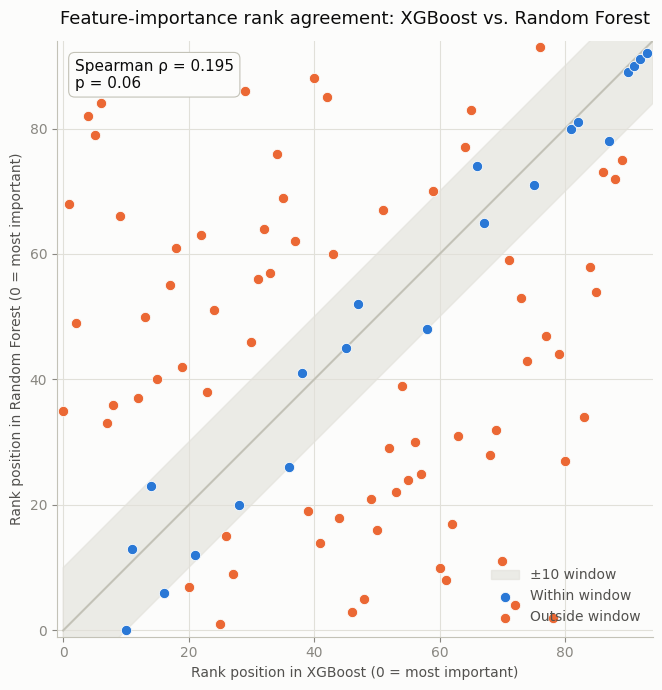

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- palette (validated categorical slots 1 & 2, light-mode chart chrome) ----
COLOR_AGREE   = "#2a78d6"   # slot 1 (blue) — within window
COLOR_DISAGREE = "#eb6834"  # slot 2 (orange) — outside window
COLOR_BAND    = "#e1e0d9"   # gridline/hairline token, used as the band fill
COLOR_DIAG    = "#c3c2b7"   # baseline/axis token
INK_PRIMARY   = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED     = "#898781"
SURFACE       = "#fcfcfb"

def plot_rank_agreement(ordered_relevance: pl.DataFrame, window: int, rho: float, p_value: float):
    x = ordered_relevance["position_xgb"].to_numpy()
    y = ordered_relevance["position_rf"].to_numpy()
    within = ordered_relevance["within_window"].to_numpy()

    n = max(x.max(), y.max()) + 1

    fig, ax = plt.subplots(figsize=(7, 7))
    fig.patch.set_facecolor(SURFACE)
    ax.set_facecolor(SURFACE)

    # ---- shaded agreement band around the diagonal (drawn first, under points) ----
    diag = np.arange(0, n + 1)
    ax.fill_between(diag, diag - window, diag + window,
                     color=COLOR_BAND, alpha=0.6, zorder=1, label=f"±{window} window")

    # ---- diagonal reference line: perfect rank agreement ----
    ax.plot([0, n], [0, n], color=COLOR_DIAG, linewidth=1.5, zorder=2)

    # ---- points, colored by agreement — fixed categorical order, never cycled ----
    ax.scatter(x[within], y[within], s=55, color=COLOR_AGREE,
               edgecolors=SURFACE, linewidths=0.6, zorder=3, label="Within window")
    ax.scatter(x[~within], y[~within], s=55, color=COLOR_DISAGREE,
               edgecolors=SURFACE, linewidths=0.6, zorder=3, label="Outside window")

    # ---- recessive grid/axes ----
    ax.grid(True, color=COLOR_BAND, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color(COLOR_DIAG)

    ax.set_xlabel("Rank position in XGBoost (0 = most important)", color=INK_SECONDARY)
    ax.set_ylabel("Rank position in Random Forest (0 = most important)", color=INK_SECONDARY)
    ax.set_title("Feature-importance rank agreement: XGBoost vs. Random Forest",
                 color=INK_PRIMARY, fontsize=13, pad=12)
    ax.tick_params(colors=INK_MUTED)
    ax.set_xlim(-1, n)
    ax.set_ylim(-1, n)
    ax.set_aspect("equal")

    # ---- Spearman rho annotation ----
    ax.text(
        0.03, 0.97,
        f"Spearman ρ = {rho:.3f}\np = {p_value:.2g}",
        transform=ax.transAxes, ha="left", va="top",
        fontsize=11, color=INK_PRIMARY,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE,
                  edgecolor=COLOR_DIAG, linewidth=0.8),
        zorder=4,
    )

    # ---- legend: identity never carried by color alone ----
    band_patch = mpatches.Patch(color=COLOR_BAND, alpha=0.6, label=f"±{window} window")
    handles, labels = ax.get_legend_handles_labels()
    handles = [band_patch] + [h for h, l in zip(handles, labels) if l != f"±{window} window"]
    labels = [f"±{window} window"] + [l for l in labels if l != f"±{window} window"]
    ax.legend(handles, labels, loc="lower right", frameon=False, labelcolor=INK_SECONDARY)

    plt.tight_layout()
    plt.show()

plot_rank_agreement(ordered_relevance, window=WINDOW, rho=rho, p_value=p_value)

### Figure interpretation:
- Points on the diagonal (inside the shaded band): features RF and XGBoost both consider similarly important. These are the most trustworthy candidates for the feature-engineering follow-up.
  
- Points far off the diagonal: features one model ranks highly and the other doesn't. Worth flagging as model-specific rather than universally important, since it suggests the "importance" is an artifact of one algorithm's structure (e.g., leaf-wise splits favoring a feature RF's bagged, shallower trees don't reach) rather than a robust signal.

- The annotated $\rho$ gives the single-number summary: close to 1 means strong overall rank agreement across all common features, close to 0 means the two models are essentially uncorrelated in what they consider important, which, combined with everything found earlier about weak overall predictive signal, would be a meaningful (if discouraging) result in its own right. According to this, the feature importance given for each model is uncorrelated, with a $\rho = 0.195$ there is almost not correlation at all. Nevertheless, the models have a higher agreement about the lest important features.

# Studying correlation of variables with target

This section will search for extremes. I will focus on studying the varaibles that are present within the widnow for each models and their correlation with the target variables in the training dataset, ds_train and target_variable_training = 'market_forward_excess_returns'). Later I will check the correlation of the variables (that are not within the window) and create a new dataset, one with the variables witht the window, their feature importance, position in each model and correlation value, and another dataset with the other variables, position in each dataset and correlation with the target variable. Both datasets will be ordered by the most to less correlated with the target

In [12]:
import polars as pl
import numpy as np
from scipy.stats import pearsonr, spearmanr

def compute_target_correlations(
    df: pl.DataFrame,
    features: list[str],
    target_col: str = "target",
) -> pl.DataFrame:
    """
    Computes Pearson and Spearman correlation between each feature and the
    target, using only rows where both are non-null (pairwise deletion,
    per feature — not a single global dropna across all features).

    Args:
        df: training DataFrame containing `target_col` and the feature columns.
        features: list of feature names to correlate against the target.
        target_col: name of the target column.

    Returns:
        pl.DataFrame with feature, pearson_r, pearson_p, spearman_r,
        spearman_p, n_obs (rows actually used per feature).
    """
    records = []
    for feat in features:
        sub = df.select([feat, target_col]).drop_nulls()
        n_obs = sub.height

        if n_obs < 3:
            records.append({
                "feature": feat, "pearson_r": None, "pearson_p": None,
                "spearman_r": None, "spearman_p": None, "n_obs": n_obs,
            })
            continue

        x = sub[feat].to_numpy()
        y = sub[target_col].to_numpy()

        pearson_r, pearson_p = pearsonr(x, y)
        spearman_r, spearman_p = spearmanr(x, y)

        records.append({
            "feature": feat,
            "pearson_r": pearson_r, "pearson_p": pearson_p,
            "spearman_r": spearman_r, "spearman_p": spearman_p,
            "n_obs": n_obs,
        })

    return pl.DataFrame(records)


# ============================================================
# Split the common feature set by window agreement
# (ordered_relevance was built in the previous step)
# ============================================================

features_within = ordered_relevance.filter(pl.col("within_window"))["feature"].to_list()
features_outside = ordered_relevance.filter(~pl.col("within_window"))["feature"].to_list()

target_variable_training = "target"  # as renamed by load_set

corr_within = compute_target_correlations(ds_train, features_within, target_col=target_variable_training)
corr_outside = compute_target_correlations(ds_train, features_outside, target_col=target_variable_training)

# ============================================================
# Dataset 1: features within the window — model-agreed importance
# + their correlation with the target
# ============================================================

within_relevance = (
    ordered_relevance
    .filter(pl.col("within_window"))
    .join(corr_within, on="feature", how="left")
    .with_columns(pl.col("pearson_r").abs().alias("abs_pearson_r"))
    .sort("abs_pearson_r", descending=True)
    .select(
        "feature", "importance_rf", "importance_xgb",
        "position_rf", "position_xgb", "window",
        "pearson_r", "pearson_p", "spearman_r", "spearman_p", "n_obs",
    )
)

# ============================================================
# Dataset 2: features outside the window — model-disagreed importance
# + their correlation with the target
# ============================================================

outside_relevance = (
    ordered_relevance
    .filter(~pl.col("within_window"))
    .join(corr_outside, on="feature", how="left")
    .with_columns(pl.col("pearson_r").abs().alias("abs_pearson_r"))
    .sort("abs_pearson_r", descending=True)
    .select(
        "feature", "importance_rf", "importance_xgb",
        "position_rf", "position_xgb", "window",
        "pearson_r", "pearson_p", "spearman_r", "spearman_p", "n_obs",
    )
)

print("Within-window features (model-agreed), ranked by |Pearson r|:")
print(within_relevance)
print("\nOutside-window features (model-disagreed), ranked by |Pearson r|:")
print(outside_relevance)

Within-window features (model-agreed), ranked by |Pearson r|:
shape: (21, 11)
┌─────────┬────────────┬────────────┬────────────┬───┬───────────┬────────────┬────────────┬───────┐
│ feature ┆ importance ┆ importance ┆ position_r ┆ … ┆ pearson_p ┆ spearman_r ┆ spearman_p ┆ n_obs │
│ ---     ┆ _rf        ┆ _xgb       ┆ f          ┆   ┆ ---       ┆ ---        ┆ ---        ┆ ---   │
│ str     ┆ ---        ┆ ---        ┆ ---        ┆   ┆ f64       ┆ f64        ┆ f64        ┆ i64   │
│         ┆ f64        ┆ f64        ┆ i64        ┆   ┆           ┆            ┆            ┆       │
╞═════════╪════════════╪════════════╪════════════╪═══╪═══════════╪════════════╪════════════╪═══════╡
│ V13     ┆ 0.039138   ┆ 0.014509   ┆ 0          ┆ … ┆ 0.004607  ┆ 0.043604   ┆ 0.000976   ┆ 5716  │
│ D4      ┆ 0.004412   ┆ 0.002939   ┆ 78         ┆ … ┆ 0.025321  ┆ 0.023283   ┆ 0.047791   ┆ 7227  │
│ M17     ┆ 0.009897   ┆ 0.010942   ┆ 45         ┆ … ┆ 0.044769  ┆ 0.022581   ┆ 0.074931   ┆ 6221  │
│ D8      ┆ 0

## Groups features into four relationship categories based on the
magnitude of their Pearson/Spearman correlation with the target,
and, for the low/low quadrant, whether tree-based importance
still ranks them as relevant. The threshold to define when a feature is important or not is calculated with the interquantile of the correlation coefficients rather than with the absolute values. This is because, as we have seen in these series of Notebooks, the target and features present low correlation values

### The categories used to classify the data are:
high_pearson = pearson_r > interquantile(person_r). Similarly, high_spearman = spearman_rho > interquantile(spearman_rho)

1. **linear (high r, high rho)**: high_pearson and high_spearman
2. **nonlinear-monotonic (low r, high rho):** low_pearson and high_spearman
3. **outlier-driven? (high r, low rho):** high_pearson and low_spearman
4. **non-monotonic/interaction (low r, low rho, tree-important):** low_pearson, low_spearman but the position of that variable for the RF and the XGBRegressor is in the upper half
5. **ikely noise (low r, low rho, low importance):** low_pearson, low_spearman, and low importance for the models

In [50]:
import polars as pl
import numpy as np

def categorize_relationship(
    df: pl.DataFrame,
    n_common_features: int,
    quantile_high: float = 0.75,  # top tercile counts as "high" by default
) -> pl.DataFrame:
    """
    Groups features into four relationship categories based on the
    magnitude of their Pearson/Spearman correlation with the target,
    and — for the low/low quadrant — whether tree-based importance
    still ranks them as relevant.

    Args:
        df: must contain feature, pearson_r, spearman_r, position_rf,
            position_xgb (as produced by earlier steps in this analysis).
        n_common_features: total number of common features (for the
            median-position threshold).
        quantile_high: quantile above which |r| / |rho| counts as "high".

    Returns:
        df with abs_pearson_r, abs_spearman_r, high_pearson, high_spearman,
        high_importance, and a "category" string column.
    """
    df = df.with_columns(
        pl.col("pearson_r").abs().alias("abs_pearson_r"),
        pl.col("spearman_r").abs().alias("abs_spearman_r"),
    )

    r_threshold = df["abs_pearson_r"].quantile(quantile_high)
    rho_threshold = df["abs_spearman_r"].quantile(quantile_high)
    median_position = n_common_features / 2

    df = df.with_columns(
        (pl.col("abs_pearson_r") >= r_threshold).alias("high_pearson"),
        (pl.col("abs_spearman_r") >= rho_threshold).alias("high_spearman"),
        (
            (pl.col("position_rf") <= median_position)
            | (pl.col("position_xgb") <= median_position)
        ).alias("high_importance"),
    )

    df = df.with_columns(
        pl.when(pl.col("high_pearson") & pl.col("high_spearman")& pl.col("high_importance"))
          .then(pl.lit("linear (high r, high rho)"))
        .when(~pl.col("high_pearson") & pl.col("high_spearman")& pl.col("high_importance"))
          .then(pl.lit("nonlinear-monotonic (low r, high rho)"))
        .when(pl.col("high_pearson") & ~pl.col("high_spearman"))
          .then(pl.lit("outlier-driven? (high r, low rho)"))
        .when(~pl.col("high_pearson") & ~pl.col("high_spearman") & pl.col("high_importance"))
          .then(pl.lit("non-monotonic/interaction (low r, low rho, tree-important)"))
        .otherwise(pl.lit("likely noise (low r, low rho, low importance)"))
        .alias("category")
    )

    print(f"Thresholds used — |r| >= {r_threshold:.4f}, |rho| >= {rho_threshold:.4f}, "
          f"position <= {median_position:.0f}")

    return df.sort("abs_pearson_r", descending=True)


# apply to both tables built in the previous step
n_common = ds_common.height  # from earlier: features common to RF & XGB

within_categorized = categorize_relationship(within_relevance, n_common)
outside_categorized = categorize_relationship(outside_relevance, n_common)

print(within_categorized.group_by("category").agg(pl.len().alias("n_features")))
print(within_categorized.select("feature", "category", "abs_pearson_r", "abs_spearman_r"))

Thresholds used — |r| >= 0.0135, |rho| >= 0.0181, position <= 47
Thresholds used — |r| >= 0.0183, |rho| >= 0.0190, position <= 47
shape: (5, 2)
┌─────────────────────────────────┬────────────┐
│ category                        ┆ n_features │
│ ---                             ┆ ---        │
│ str                             ┆ u32        │
╞═════════════════════════════════╪════════════╡
│ nonlinear-monotonic (low r, hi… ┆ 2          │
│ outlier-driven? (high r, low r… ┆ 2          │
│ non-monotonic/interaction (low… ┆ 4          │
│ linear (high r, high rho)       ┆ 2          │
│ likely noise (low r, low rho, … ┆ 11         │
└─────────────────────────────────┴────────────┘
shape: (21, 4)
┌─────────┬─────────────────────────────────┬───────────────┬────────────────┐
│ feature ┆ category                        ┆ abs_pearson_r ┆ abs_spearman_r │
│ ---     ┆ ---                             ┆ ---           ┆ ---            │
│ str     ┆ str                             ┆ f64           ┆ f64

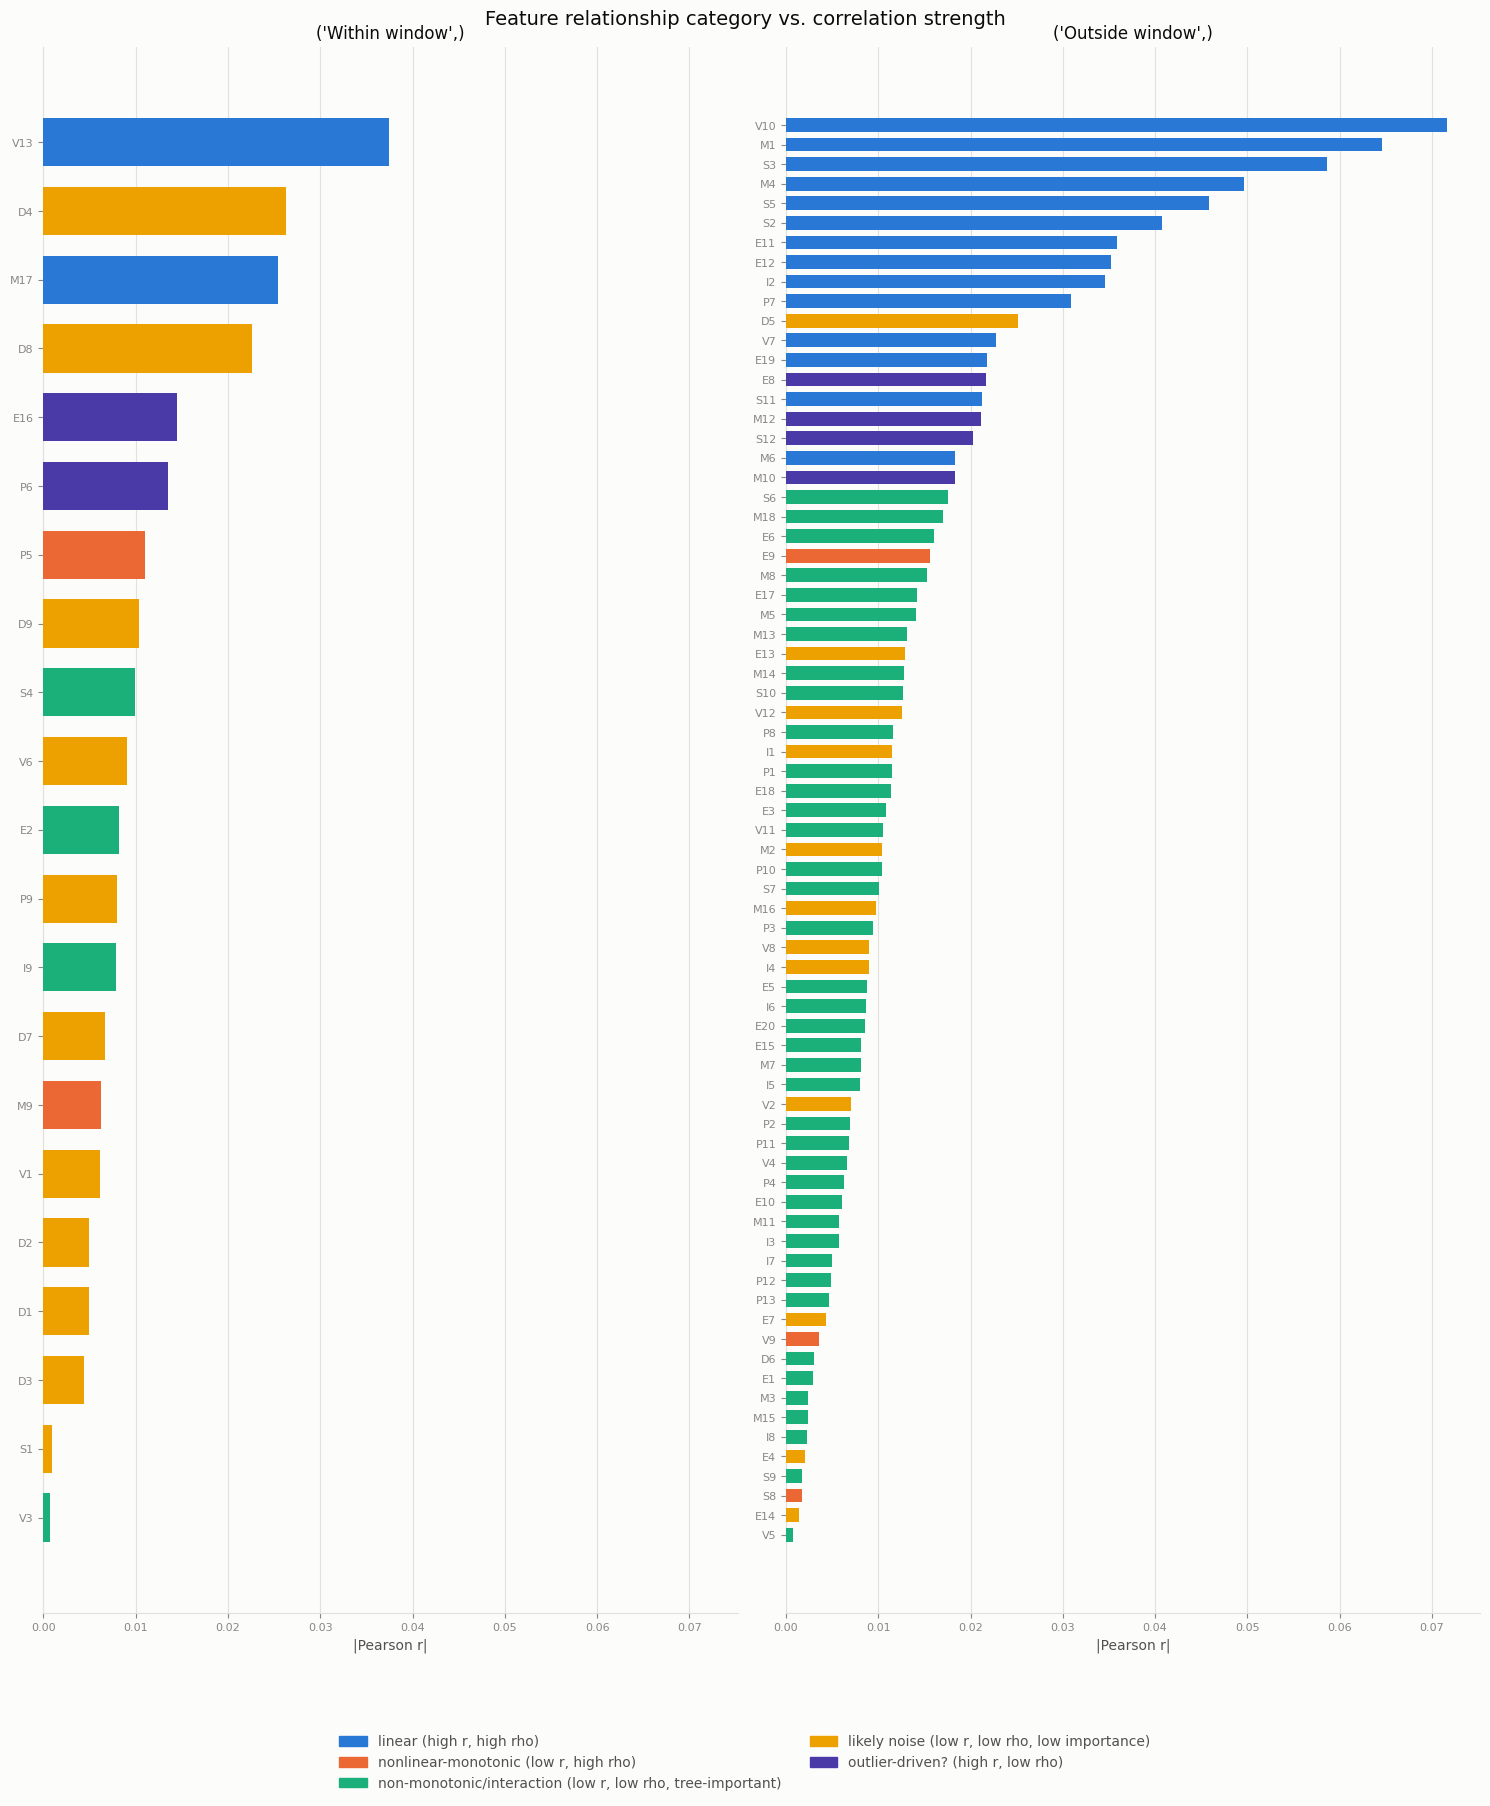

In [51]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- validated categorical palette, fixed order (4 slots — adjacent-pairlist gate applies to bar charts) ----
CATEGORY_COLORS = {
    "linear (high r, high rho)":                                  "#2a78d6",  # slot 1 blue
    "nonlinear-monotonic (low r, high rho)":                      "#eb6834",  # slot 2 orange
    "non-monotonic/interaction (low r, low rho, tree-important)": "#1baf7a",  # slot 3 aqua
    "likely noise (low r, low rho, low importance)":              "#eda100",  # slot 4 yellow
    "outlier-driven? (high r, low rho)":                          "#4a3aa7",  # slot 7 violet — rare cell, distinct flag color
}
CATEGORY_ORDER = list(CATEGORY_COLORS.keys())

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, SURFACE = "#e1e0d9", "#fcfcfb"

# ============================================================
# Merge the two categorized tables, tagging which group each came from
# ============================================================
merged = pl.concat([
    within_categorized.with_columns(pl.lit("Within window").alias("group")),
    outside_categorized.with_columns(pl.lit("Outside window").alias("group")),
])

def plot_categories(merged: pl.DataFrame):
    fig, axes = plt.subplots(1, 2, figsize=(15, max(6, merged.height * 0.18)), sharex=True)
    fig.patch.set_facecolor(SURFACE)

    for ax, (group_name, sub) in zip(axes, merged.group_by("group", maintain_order=True)):
        sub = sub.sort("abs_pearson_r", descending=False)  # ascending so largest bar is on top
        colors = [CATEGORY_COLORS[c] for c in sub["category"]]

        ax.set_facecolor(SURFACE)
        ax.barh(sub["feature"], sub["abs_pearson_r"], color=colors, height=0.7, zorder=3)

        ax.set_title(group_name, color=INK_PRIMARY, fontsize=12)
        ax.set_xlabel("|Pearson r|", color=INK_SECONDARY)
        ax.tick_params(colors=INK_MUTED, labelsize=8)
        ax.grid(True, axis="x", color=GRID, linewidth=0.8, zorder=0)
        ax.set_axisbelow(True)
        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_color(GRID)

    # single shared legend, fixed category order (never re-sorted by frequency)
    handles = [mpatches.Patch(color=CATEGORY_COLORS[c], label=c) for c in CATEGORY_ORDER
               if c in merged["category"].unique().to_list()]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False,
               labelcolor=INK_SECONDARY, bbox_to_anchor=(0.5, -0.08))

    fig.suptitle("Feature relationship category vs. correlation strength", color=INK_PRIMARY, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_categories(merged)

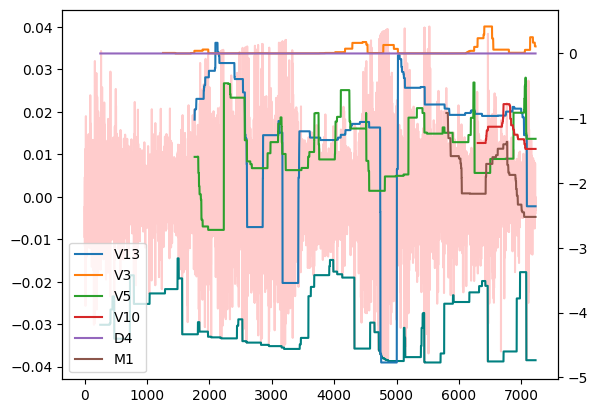

In [52]:
fig, ax = plt.subplots()

n_range = np.arange(ds_train.height)
variable = ["V13","V3","V5","V10","D4","M1"]


roll_mean = 252 #252: one tradding year
ax2 = ax.twinx()

ax.plot(n_range,ds_train['target'], color = "red",alpha=0.2)
ax.plot(n_range,ds_train['target'].rolling_min(roll_mean), label='target', color = "teal")
for var in variable:
    ax2.plot(n_range,ds_train[var].rolling_min(roll_mean), label=var)

plt.legend()

# Removing features identified as noise


In [60]:
import polars as pl

# ============================================================
# 1. Identify features labeled "likely noise" from the merged
#    categorization table built earlier (within_categorized + outside_categorized)
# ============================================================

NOISE_LABEL = "likely noise (low r, low rho, low importance)"

noise_features = (
    merged
    .filter(pl.col("category") == NOISE_LABEL)
    .select("feature")
    .unique()
    .to_series()
    .to_list()
)

print(f"Features flagged as '{NOISE_LABEL}': {len(noise_features)}")
print(sorted(noise_features))

# ============================================================
# 2. Drop these features from the training and test sets.
#    Only drop columns actually present in each dataset — guards against
#    a mismatch if ds_train/ds_test schemas ever diverge (e.g. one was
#    rebuilt independently of the categorization step).
# ============================================================

def drop_noise_features(df: pl.DataFrame, noise_features: list[str]) -> pl.DataFrame:
    cols_to_drop = [f for f in noise_features if f in df.columns]
    missing = [f for f in noise_features if f not in df.columns]
    if missing:
        print(f"Warning: {len(missing)} noise feature(s) not found in this DataFrame, skipped: {missing}")
    return df.drop(cols_to_drop)

ds_train_clean = drop_noise_features(ds_train, noise_features)
ds_test_clean = drop_noise_features(ds_test, noise_features)

print(f"ds_train: {ds_train.width} -> {ds_train_clean.width} columns")
print(f"ds_test:  {ds_test.width} -> {ds_test_clean.width} columns")

# keep the modeling feature list in sync for any downstream cell that reuses FEATURES
FEATURES_CLEAN = [f for f in FEATURES if f not in noise_features]

# ============================================================
# 3. Save as notebook output: cleaned datasets + a record of what was dropped
#    (the latter matters for reproducibility — future you, or a reviewer,
#    should be able to see exactly which features were removed and why)
# ============================================================
import os
OUT_DIR = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

ds_train_clean.write_csv(f"{OUT_DIR}/ds_train_no_noise.csv")
ds_test_clean.write_csv(f"{OUT_DIR}/ds_test_no_noise.csv")

pl.DataFrame({"feature": sorted(noise_features)}).write_csv(f"{OUT_DIR}/dropped_noise_features.csv")

print(f"Saved cleaned train/test sets and dropped-feature list to {OUT_DIR}")

Features flagged as 'likely noise (low r, low rho, low importance)': 23
['D1', 'D2', 'D3', 'D4', 'D5', 'D7', 'D8', 'D9', 'E13', 'E14', 'E4', 'E7', 'I1', 'I4', 'M16', 'M2', 'P9', 'S1', 'V1', 'V12', 'V2', 'V6', 'V8']
ds_train: 98 -> 75 columns
ds_test:  98 -> 75 columns
Saved cleaned train/test sets and dropped-feature list to /kaggle/working
